<a href="https://colab.research.google.com/github/SSLJ/Skin-tone-based-outfit-recommendation/blob/main/Men%E2%80%99s_Wardrobe_Management_and_Color_Based_Outfit_Recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jangedoo/utkface-new")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'utkface-new' dataset.
Path to dataset files: /kaggle/input/utkface-new


In [ ]:
import pandas as pd
import numpy as np
import os

print(os.listdir(path)) # listing the folders in path

['UTKFace', 'utkface_aligned_cropped', 'crop_part1']


In [ ]:
utkface_aligned_cropped_path = os.path.join(path, "utkface_aligned_cropped") # calling utkface_aligned_cropped path
print(f"Path to utkface_aligned_cropped folder: {utkface_aligned_cropped_path}")


Path to utkface_aligned_cropped folder: /kaggle/input/utkface-new/utkface_aligned_cropped


Path to images in UTKFace folder: /kaggle/input/utkface-new/utkface_aligned_cropped/UTKFace
Found 23708 image files in UTKFace folder.


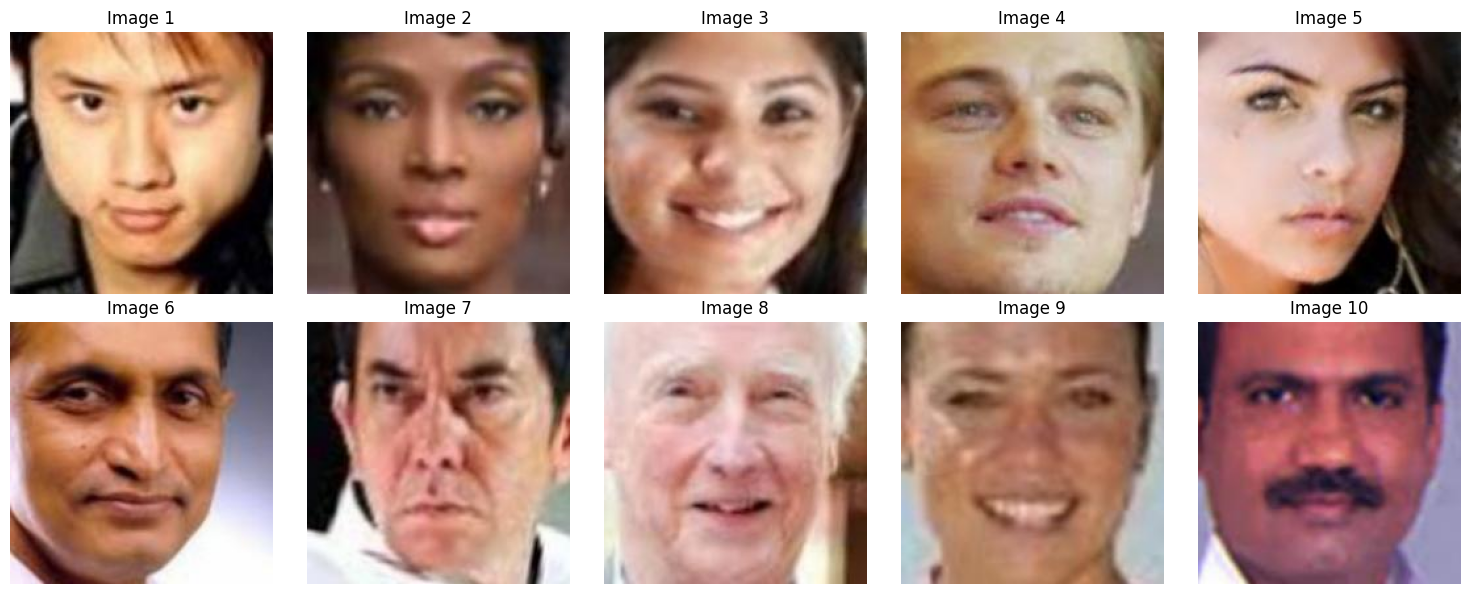

Successfully loaded 10 images.


In [ ]:
import os
from PIL import Image # pillow library \\strong image preprocessing library
import matplotlib.pyplot as plt

utkface_utkface_path = os.path.join(utkface_aligned_cropped_path, "UTKFace") # calling path to  utkface folder
print(f"Path to images in UTKFace folder: {utkface_utkface_path}")

image_files = [f for f in os.listdir(utkface_utkface_path) if f.endswith(('.jpg', '.png', '.jpeg'))] # inside utkface extracting all files end with jpg,png and jpeg
print(f"Found {len(image_files)} image files in UTKFace folder.") # total no. of image files

loaded_images = [] # to store the loaded images

plt.figure(figsize=(15, 6)) # figure to display
for i, image_file in enumerate(image_files[:10]): # calling first 10 images
    image_path = os.path.join(utkface_utkface_path, image_file)  # finding the path to the particular image file
    try:
        img = Image.open(image_path) # load the image
        loaded_images.append(img) # appending the loaded image to array

        plt.subplot(2, 5, i + 1) # Arrange in 2 rows, 5 columns
        plt.imshow(img) # used to show image
        plt.title(f"Image {i+1}")
        plt.axis('off') # turn off labels
    except Exception as e:
        print(f"Could not load {image_file}: {e}")
plt.tight_layout() # auto adjust subplot
plt.show()

print(f"Successfully loaded {len(loaded_images)} images.")

In [ ]:
print("Resolutions of the first 10 loaded images:")
for i, img in enumerate(loaded_images):
    width, height = img.size
    print(f"Image {i+1}: {width}x{height}")

Resolutions of the first 10 loaded images:
Image 1: 200x200
Image 2: 200x200
Image 3: 200x200
Image 4: 200x200
Image 5: 200x200
Image 6: 200x200
Image 7: 200x200
Image 8: 200x200
Image 9: 200x200
Image 10: 200x200


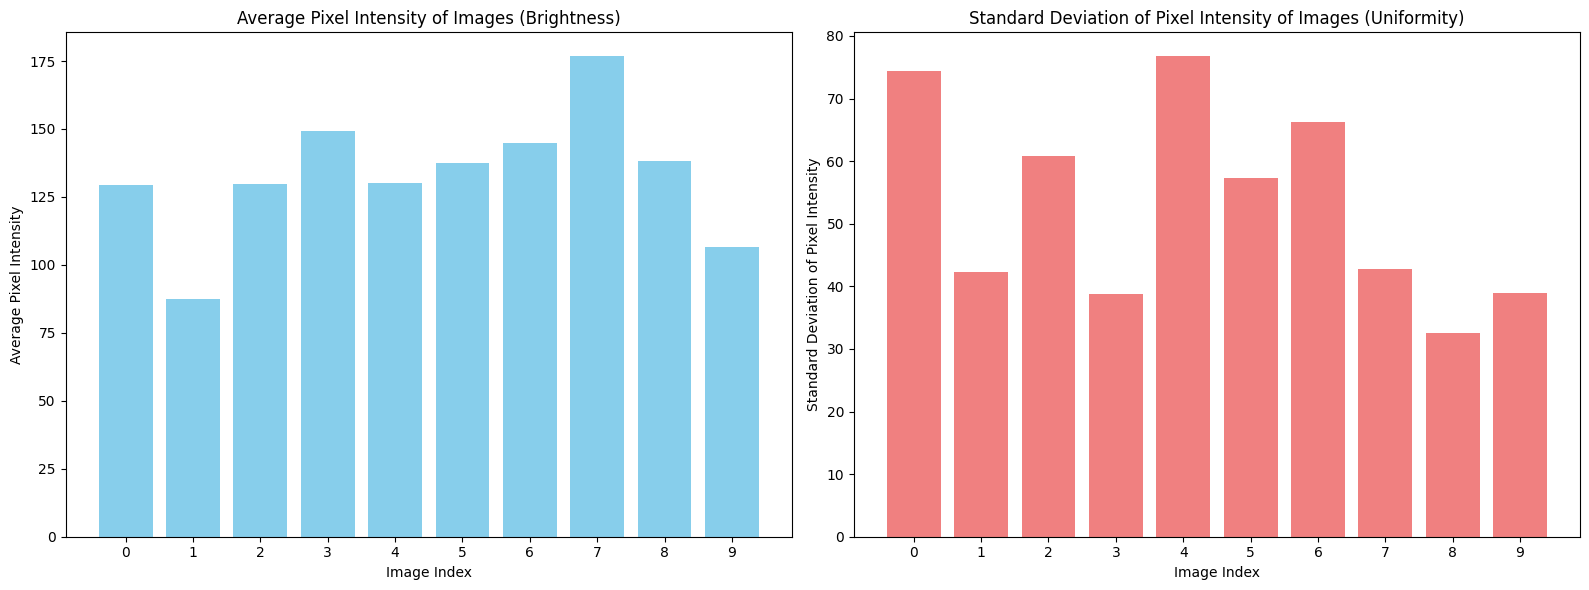

Calculated average pixel intensities: ['129.29', '87.47', '129.58', '149.26', '130.06', '137.58', '144.91', '176.72', '138.06', '106.72']
Calculated standard deviations of pixel intensities: ['74.41', '42.32', '60.79', '38.82', '76.75', '57.28', '66.22', '42.71', '32.61', '38.93']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Initialize lists to store metrics
average_intensities = []
std_dev_intensities = []

# Process each loaded image
for img in loaded_images:
    # Convert image to grayscale
    gray_img = img.convert('L')

    # Convert grayscale image to a NumPy array
    img_array = np.array(gray_img)

    # Calculate average pixel intensity (brightness)
    avg_intensity = np.mean(img_array)
    average_intensities.append(avg_intensity)

    # Calculate standard deviation of pixel intensities (uniformity)
    std_dev = np.std(img_array)
    std_dev_intensities.append(std_dev)

# Visualize the lighting metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot for Average Pixel Intensity
axes[0].bar(range(len(average_intensities)), average_intensities, color='skyblue')
axes[0].set_xlabel('Image Index')
axes[0].set_ylabel('Average Pixel Intensity')
axes[0].set_title('Average Pixel Intensity of Images (Brightness)')
axes[0].set_xticks(range(len(average_intensities)))

# Bar plot for Standard Deviation of Pixel Intensity
axes[1].bar(range(len(std_dev_intensities)), std_dev_intensities, color='lightcoral')
axes[1].set_xlabel('Image Index')
axes[1].set_ylabel('Standard Deviation of Pixel Intensity')
axes[1].set_title('Standard Deviation of Pixel Intensity of Images (Uniformity)')
axes[1].set_xticks(range(len(std_dev_intensities)))

plt.tight_layout()
plt.show()

print("Calculated average pixel intensities:", [f'{x:.2f}' for x in average_intensities])
print("Calculated standard deviations of pixel intensities:", [f'{x:.2f}' for x in std_dev_intensities])

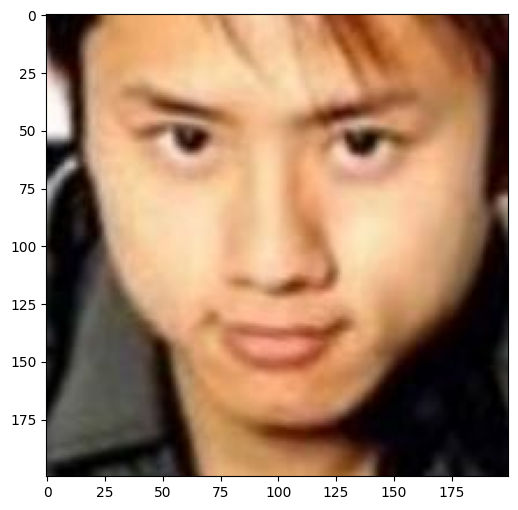

In [ ]:
plt.figure(figsize=(15, 6))
plt.imshow(loaded_images[0])
plt.show()

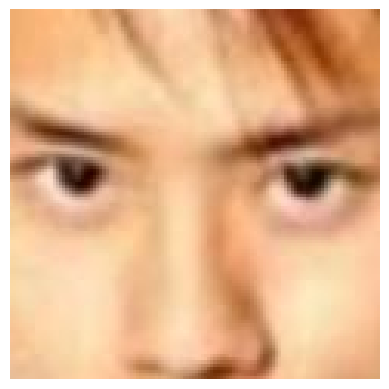

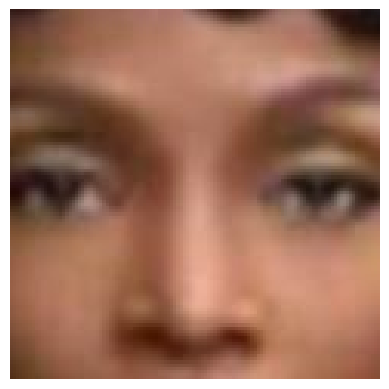

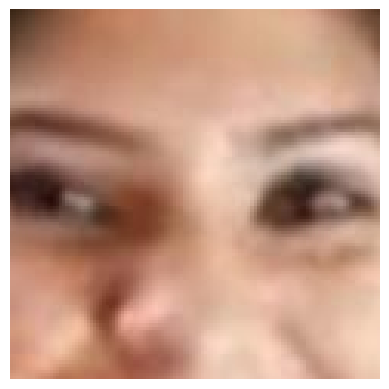

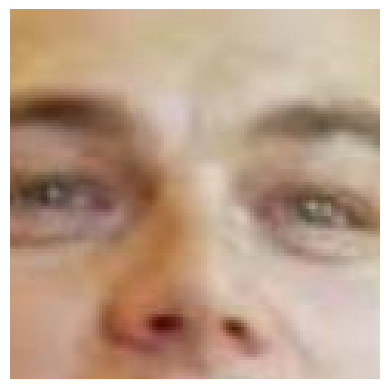

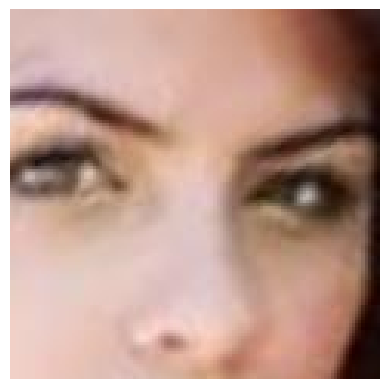

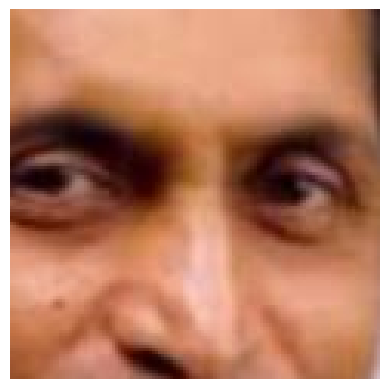

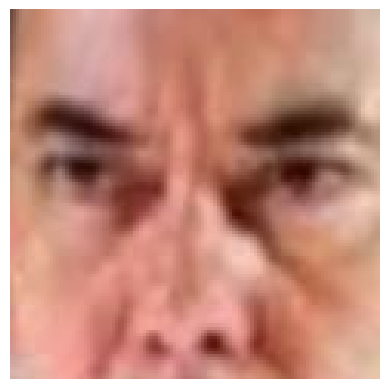

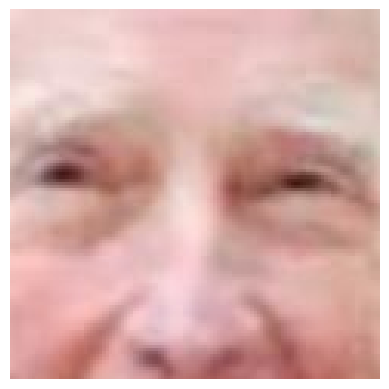

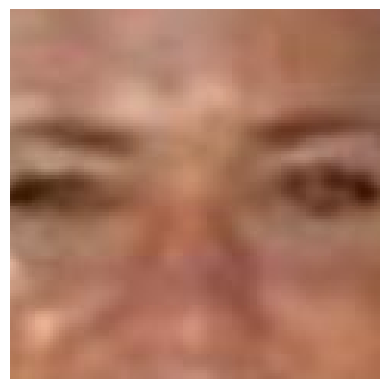

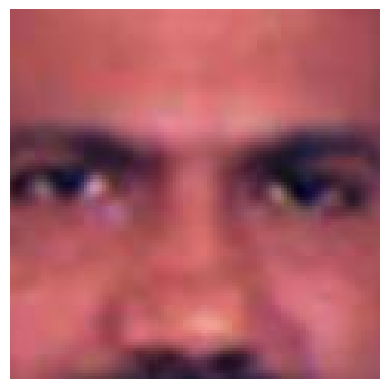

In [ ]:
cropped_images = []

for img in loaded_images:
  roi=np.array(img) # convert the image object to a NumPy array
  h,w = roi.shape[:2] # height and width from shape

  top=int(0*h)
  bottom=int(0.6*h)
  left=int(0.2*w)
  right=int(0.8*w)

  skin=roi[top:bottom,left:right]
  cropped_images.append(skin)
  plt.imshow(skin)
  plt.axis('off')
  plt.show()

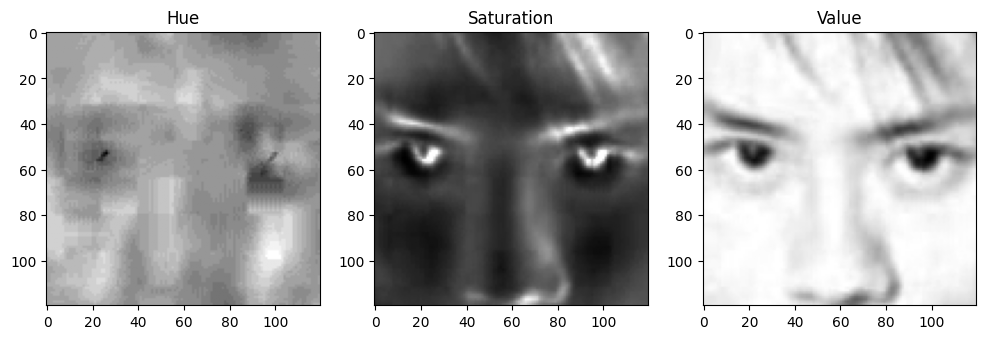

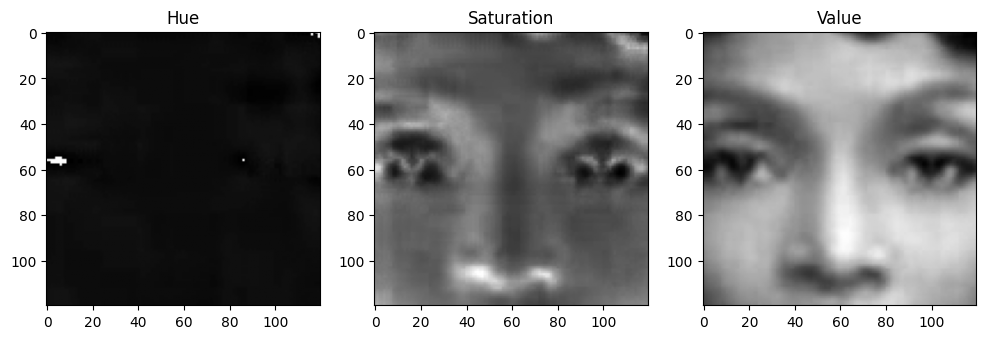

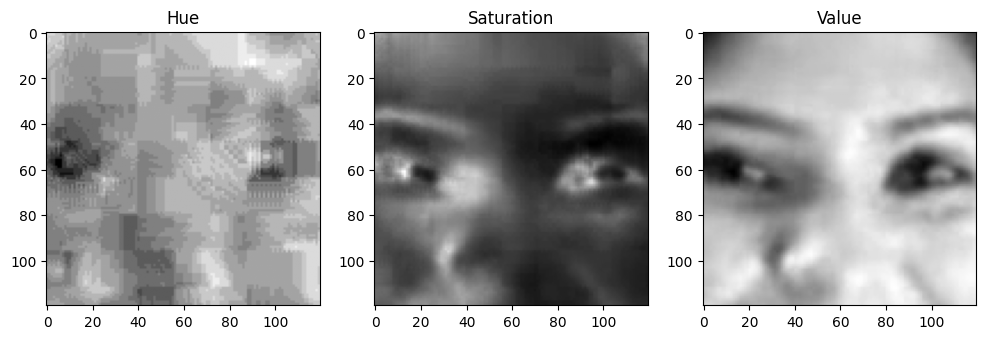

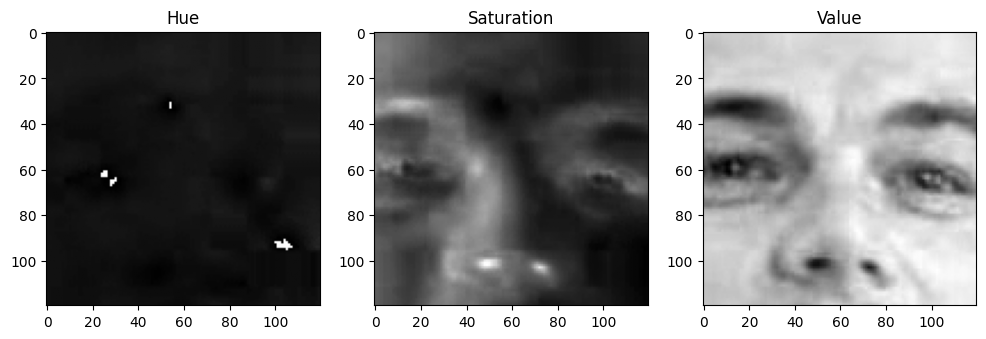

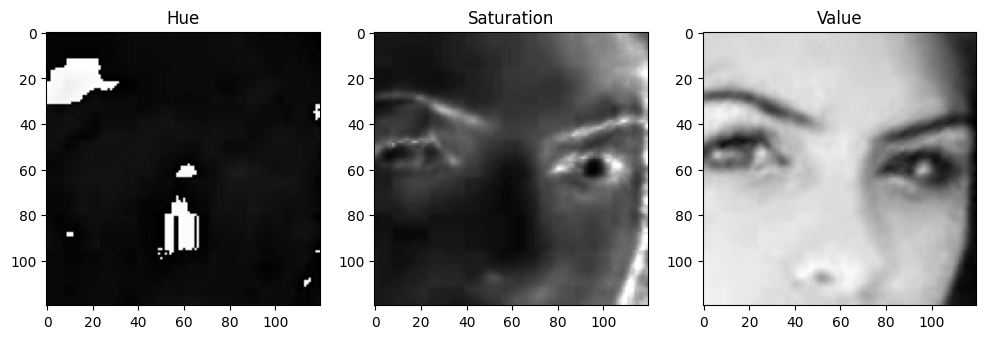

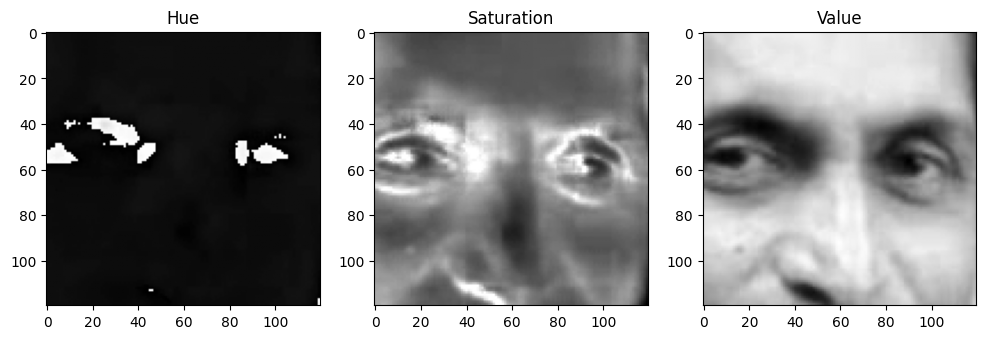

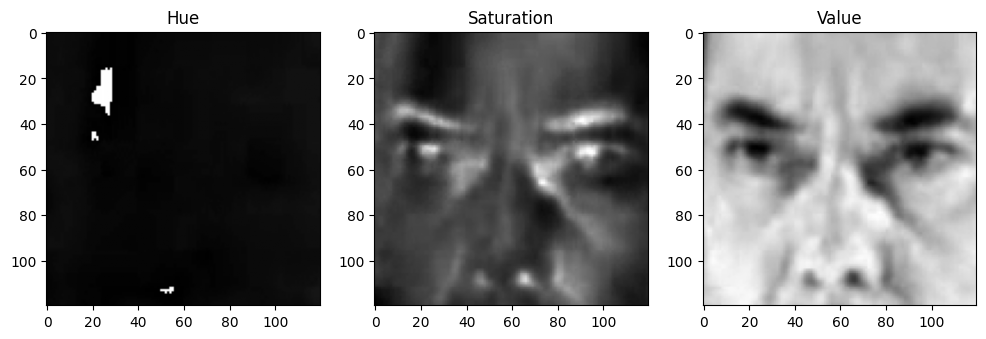

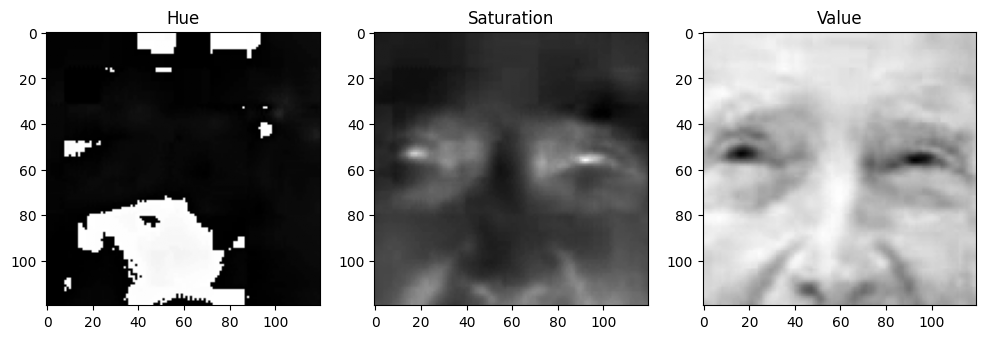

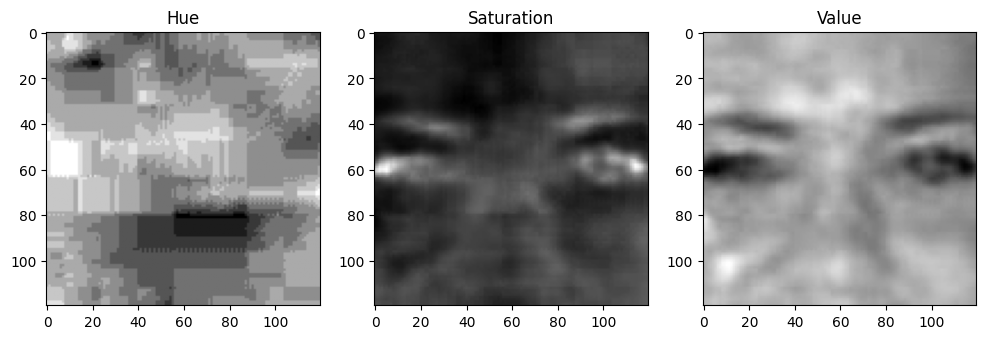

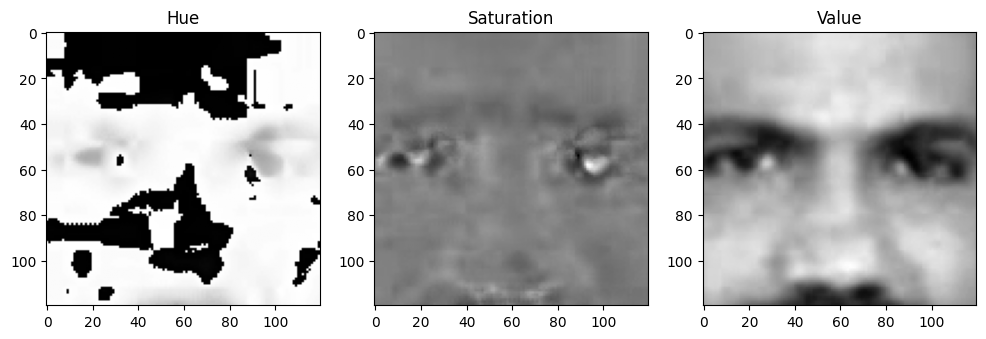

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

for img_cropped in cropped_images:

  hsv_img = cv2.cvtColor(img_cropped, cv2.COLOR_RGB2HSV) # converted RGB to HSV

  hue=hsv_img[:,:,0] # actual color
  saturation=hsv_img[:,:,1] # intensity
  value=hsv_img[:,:,2] # brightness/lightning

  plt.figure(figsize=(12,4))

  plt.subplot(1,3,1)
  plt.imshow(hue, cmap='gray')
  plt.title("Hue")

  plt.subplot(1,3,2)
  plt.imshow(saturation, cmap='gray')
  plt.title("Saturation")

  plt.subplot(1,3,3)
  plt.imshow(value, cmap='gray')
  plt.title("Value")

  plt.show()

In [ ]:
import numpy as np

total_pixels=[]
for img_cropped in cropped_images:
  hsv_img = cv2.cvtColor(img_cropped, cv2.COLOR_RGB2HSV)

  hue=hsv_img[:,:,0]
  saturation=hsv_img[:,:,1]

  pixels = np.stack([hue.flatten(),saturation.flatten()],axis=1) # taking (h,s) of all images
  total_pixels.append(pixels)


In [ ]:
from sklearn.cluster import KMeans

cluster_centre=[]
for img_data in total_pixels:
  k=5
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(img_data)

  cluster_c=kmeans.cluster_centers_ # coordinates of the clusters
  cluster_c.shape = (k, 2)# k=5, 2=(h,s)
  cluster_centre.append(cluster_c)


In [ ]:
import cv2

palette = []

for image_cluster_centers in cluster_centre:
    for h_s_pair in image_cluster_centers:
        h, s = int(h_s_pair[0]), int(h_s_pair[1]) # hue and saturation in i/5 clusters
        v = 200  # fixed brightness for consistent lightning making h,s different for each image

        hsv_pixel = np.uint8([[[h, s, v]]])# hsv pixel 3D array
        rgb_pixel = cv2.cvtColor(hsv_pixel, cv2.COLOR_HSV2RGB)[0][0] # convert hsv to rgb
        palette.append(rgb_pixel)


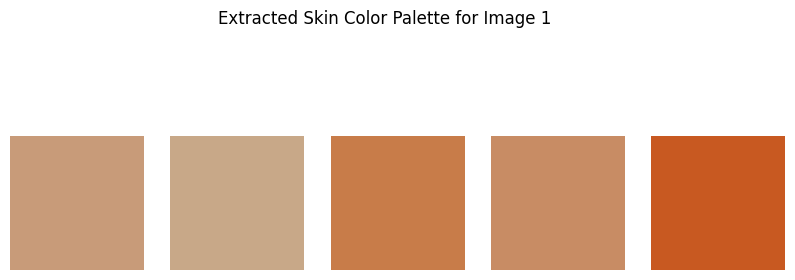

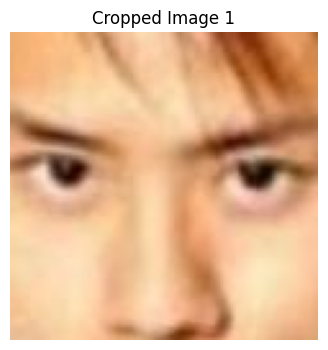

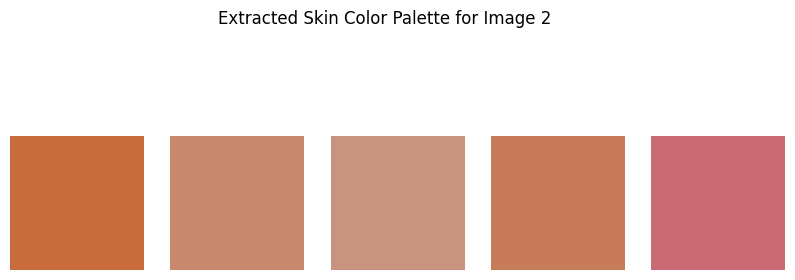

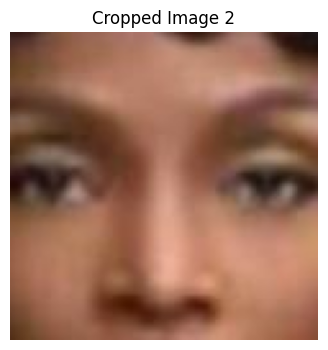

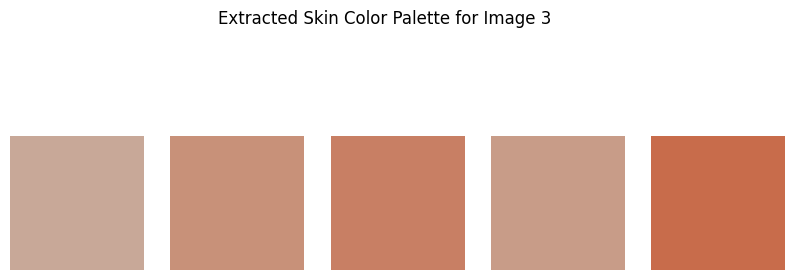

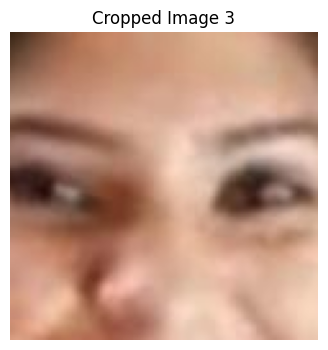

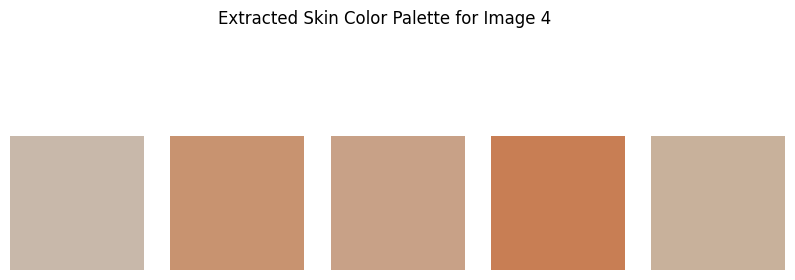

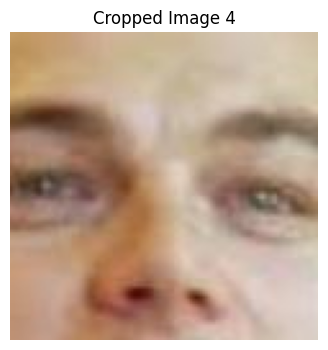

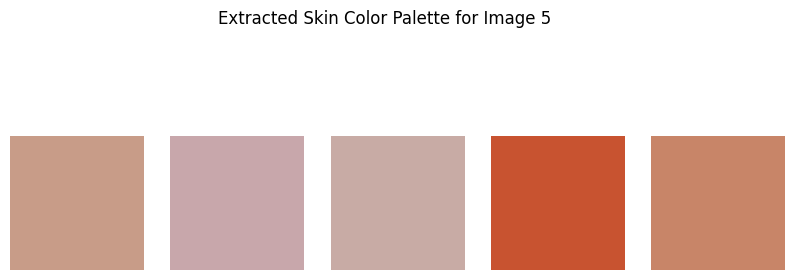

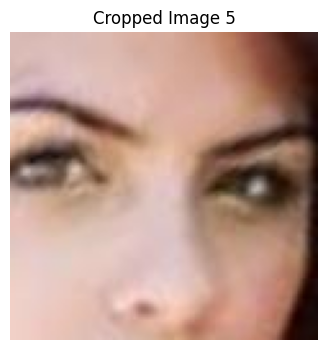

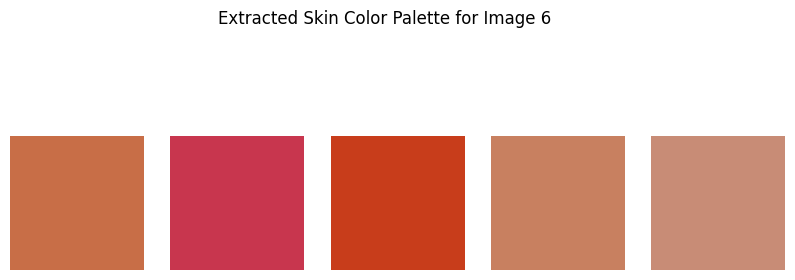

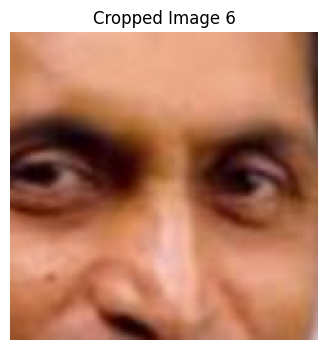

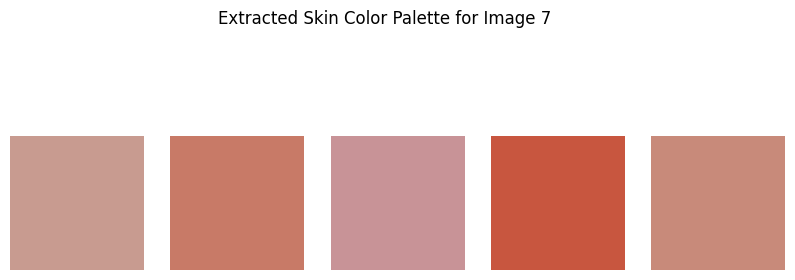

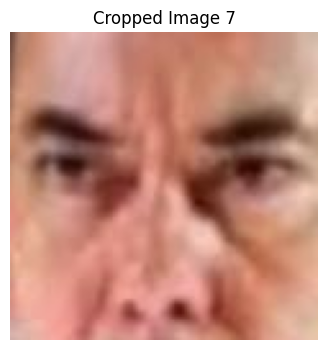

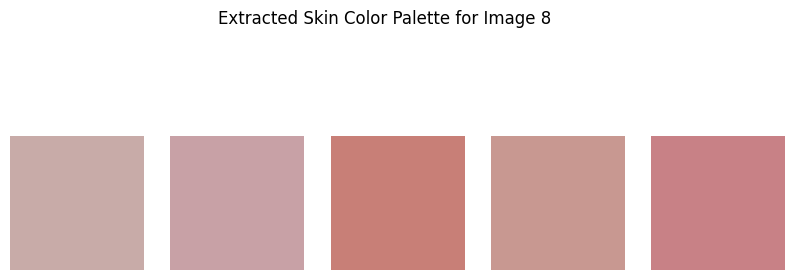

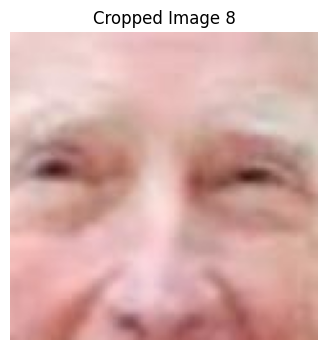

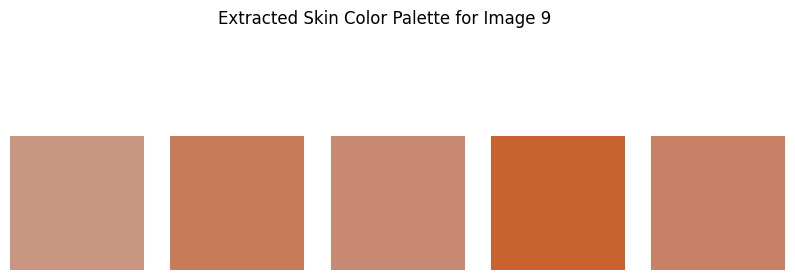

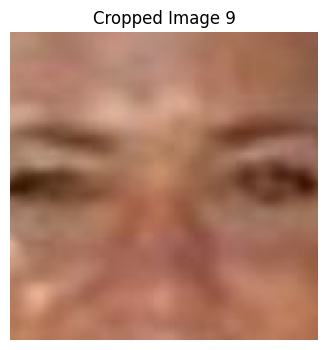

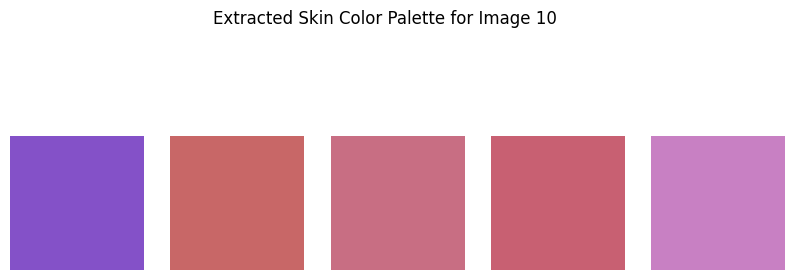

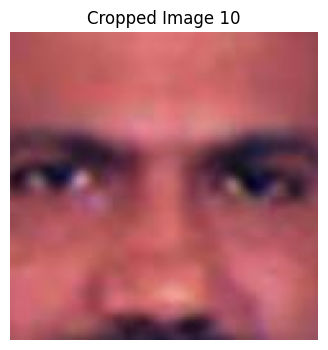

In [ ]:
color_idx_start = 0
for idx, img_cropped in enumerate(cropped_images):
  plt.figure(figsize=(10, 4)) # Adjust figure size for better display

  # Get the k colors relevant to the current image
  current_image_palette = palette[color_idx_start : color_idx_start + k]

  # Plot the palette colors
  for i, color in enumerate(current_image_palette):
      plt.subplot(1, k, i + 1) # This now correctly iterates i+1 from 1 to k
      plt.imshow([[color]])
      plt.axis("off")
  plt.suptitle(f"Extracted Skin Color Palette for Image {idx+1}")
  # plt.show() # Not showing here to combine with the image

  # Plot the corresponding cropped image
  plt.figure(figsize=(4,4))
  plt.imshow(img_cropped)
  plt.title(f"Cropped Image {idx+1}")
  plt.axis('off')
  plt.show() # Display both the palette and the image together

  color_idx_start += k # Move the starting index for the next set of k colors

In [ ]:
import numpy as np

features_list=[]
for i in range(len(cropped_images)):
  for cluster_centre_ in cluster_centre:
    hues=cluster_centre_[:,0]
    sat=cluster_centre_[:,1]

    features = {
        "mean hue": np.mean(hues),
        "mean saturation": np.mean(sat),
        "std hue": np.std(hues),
        "std saturation": np.std(sat),
        "warm ratio": np.sum(hues < 25 )/len(hues)
    }
    features_list.append(features)

print(features_list)

[{'mean hue': np.float64(12.904362812709468), 'mean saturation': np.float64(137.48747509686376), 'std hue': np.float64(1.5061511841204331), 'std saturation': np.float64(46.9114265291529), 'warm ratio': np.float64(1.0)}, {'mean hue': np.float64(42.88641134923324), 'mean saturation': np.float64(130.10596556947797), 'std hue': np.float64(67.07758584490948), 'std saturation': np.float64(27.802608974692323), 'warm ratio': np.float64(0.8)}, {'mean hue': np.float64(9.355371284462862), 'mean saturation': np.float64(106.61989672849536), 'std hue': np.float64(0.6862261683880169), 'std saturation': np.float64(34.657609806142055), 'warm ratio': np.float64(1.0)}, {'mean hue': np.float64(13.11609400808591), 'mean saturation': np.float64(88.46423882360205), 'std hue': np.float64(1.4816851980640402), 'std saturation': np.float64(39.12333200713142), 'warm ratio': np.float64(1.0)}, {'mean hue': np.float64(41.667930987498835), 'mean saturation': np.float64(97.46422307077596), 'std hue': np.float64(67.252

In [ ]:
import pandas as pd

df_features=pd.DataFrame(features_list)
df_features.head()


,mean hue,mean saturation,std hue,std saturation,warm ratio
0,12.904363,137.487475,1.506151,46.911427,1.0
1,42.886411,130.105966,67.077586,27.802609,0.8
2,9.355371,106.619897,0.686226,34.657610,1.0
3,13.116094,88.464239,1.481685,39.123332,1.0
4,41.667931,97.464223,67.252799,56.362653,0.8


In [ ]:
from sklearn.model_selection import train_test_split

X= df_features
X_train,X_test = train_test_split(X,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
print(X_train.shape)
print(X_test.shape)


(80, 5)
(20, 5)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report

df_features['label']=(df_features['mean hue'] < 25).astype(int)

X=df_features.drop('label',axis=1)
y=df_features['label']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

scalwer=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)

y_rf=rf.predict(X_test)

print(accuracy_score(y_test,y_rf))
print(classification_report(y_test,y_rf))

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        13

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

